# Занятие 38. Практика: bagging и случайный лес (~90 мин)

**Только для преподавателя. Не выдавать студентам.**

Эталон практики. Ячейку **«Дано»** не меняйте.

Главная модель — **RandomForestClassifier** (теория — занятие 37, `bagging_random_forest_theory.ipynb`).

Сравним одно дерево, bagging и random forest; настроим `n_estimators`, посмотрим OOB (пп. 7–10 теории).

Термины и определения — в теоретическом ноутбуке. Здесь только практика.

---
## Дано: make_classification

20 признаков, бинарная классификация — как в теории (п. 8).

In [1]:
import numpy as np
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, n_features=20, n_informative=7, flip_y=0.08, random_state=42
)
print('Объектов:', len(X))

Объектов: 1000


---
## Задание 0. Split (~8 мин)

Импорты: `train_test_split`, `DecisionTreeClassifier`, `BaggingClassifier`, `RandomForestClassifier`, `accuracy_score`, `permutation_importance`. Split 70/30, stratify, `RANDOM_STATE=42`.

**Критерий:** train/val готовы.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

---
## Задание 1. Три модели (~15 мин)

По п. 8. Одно дерево, bagging (150 estimators), random forest (150). Train и validation accuracy.

**Критерий:** лес ≥ bagging ≥ одно дерево на validation (обычно).

In [3]:
models = {
    'одно дерево': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'bagging': BaggingClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
    'random forest': RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    va = accuracy_score(y_val, m.predict(X_val))
    print(f'{name}: train={tr:.3f} val={va:.3f}')

одно дерево: train=1.000 val=0.750


bagging: train=1.000 val=0.847


random forest: train=1.000 val=0.820


---
## Задание 2. n_estimators (~15 мин)

По п. 9–10. График validation accuracy vs `n_estimators` in `[1,5,20,60,150,300]`.

**Критерий:** кривая выходит на плато.

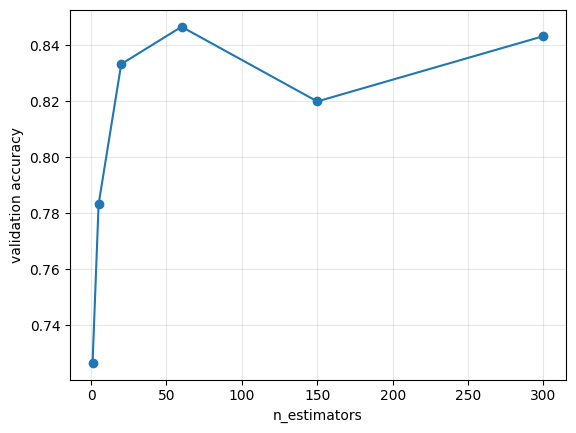

In [4]:
import matplotlib.pyplot as plt

counts = [1, 5, 20, 60, 150, 300]
scores = []
for n in counts:
    m = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
    scores.append(accuracy_score(y_val, m.predict(X_val)))
plt.plot(counts, scores, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('validation accuracy')
plt.grid(alpha=0.3)
plt.show()

---
## Задание 3. OOB score (~10 мин)

По п. 7. `RandomForestClassifier(oob_score=True, n_estimators=300)`. Сравните OOB и validation accuracy.

**Критерий:** оба числа напечатаны.

In [5]:
forest_oob = RandomForestClassifier(
    n_estimators=300, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1
).fit(X_train, y_train)
print('OOB:', round(forest_oob.oob_score_, 3))
print('Val:', round(accuracy_score(y_val, forest_oob.predict(X_val)), 3))

OOB: 0.853
Val: 0.843


---
## Задание 4. max_depth (~12 мин)

Подберите `max_depth` in `[None, 5, 10, 20]` при `n_estimators=150`. Лучший по validation.

**Критерий:** `best_depth` выбран.

In [6]:
best = (-1, None)
for d in [None, 5, 10, 20]:
    m = RandomForestClassifier(n_estimators=150, max_depth=d, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
    va = accuracy_score(y_val, m.predict(X_val))
    if va > best[0]:
        best = (va, d)
print('best max_depth:', best[1], 'val acc:', round(best[0], 3))

best max_depth: 10 val acc: 0.857


---
## Задание 5. Bootstrap вручную (~12 мин)

По п. 2. Сгенерируйте bootstrap-индексы длины n из `len(X_train)` с `replace=True`. Сколько **уникальных** объектов в среднем попадёт в выборку? (100 повторов)

**Критерий:** ~632 при n=1000 (63.2%).

In [7]:
rng = np.random.default_rng(RANDOM_STATE)
n = len(X_train)
uniq = [len(np.unique(rng.choice(n, n, replace=True))) for _ in range(100)]
print('Среднее уникальных:', round(np.mean(uniq), 1))

Среднее уникальных: 441.9


---
## Задание 6. Permutation importance (~15 мин)

По п. 15. `permutation_importance` для леса на validation, top-5 признаков.

**Критерий:** barh или таблица top-5.

In [8]:
rf = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
perm = permutation_importance(rf, X_val, y_val, n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1)
top = np.argsort(perm.importances_mean)[-5:]
for i in top:
    print(f'x{i}: {perm.importances_mean[i]:.4f}')

x19: -0.0021
x7: 0.0021
x9: 0.0125
x5: 0.0208
x14: 0.0929


---
## Задание 7. Train vs val gap (~8 мин)

В markdown: почему у леса большой train acc не всегда означает переобучение? (п. 9)

**Критерий:** 2–3 предложения.

---
## Задание 8. Итог (~5 мин)

Сравните bagging и RF в одном предложении каждый.

**Критерий:** markdown.